### Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from tqdm import tqdm

import matplotlib as mpl

from matplotlib.collections import LineCollection

import os, sys
# sys.path.append(os.path.join(os.getcwd(), '..', 'rctorch'))

from rctorch.models import MorrisLecar, MorrisLecarCurrent
from rctorch.utils import z_transform

In [2]:
save_dir = os.path.join(os.getcwd(), "img", "ml")
os.makedirs(save_dir, exist_ok=True)

In [3]:
T = 10000
dt = 1e-1
t = np.arange(0, T, dt)

### Run Models

#### Preparing functions

#### Run Current-Based Model model

In [6]:
## TORCH SETUP
seed = 51
np.random.seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')
print(f"Using Device <{device}> for PyTorch computations...\n")
torch.cuda.random.manual_seed(seed)

Using Device <cuda> for PyTorch computations...



In [7]:
Ne = 400
Ni = 100
# N = Ne + Ni

# input current for I and E neurons
Ie = 65
Ii = 65
current = np.array([Ie] * Ne + [Ii] * Ni).reshape(-1, 1)

# current = Ie
p = 0.01
gbar = 8.5
Q = 0

# x = np.zeros(shape=x.shape, dtype=float)
ml = MorrisLecarCurrent(
    dt=dt, Ne=Ne, Ni=Ni, BIAS=current, gbar=gbar, device=device, p_sparsity=p
)

ml.w = ml.w.type(torch.float32)

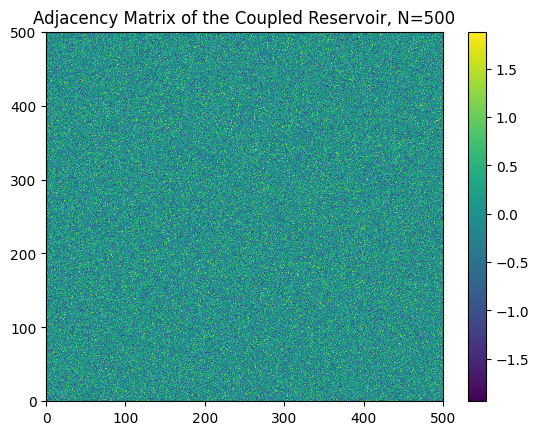

In [8]:
clr = plt.pcolormesh(ml.w.cpu().numpy(), cmap="viridis")
plt.colorbar(clr)
plt.title(f"Adjacency Matrix of the Coupled Reservoir, N={ml.N}")
# plt.savefig("img/weight_matrix.jpg", dpi=300, bbox_inches='tight')
plt.show()

In [9]:
print("mean abs:", ml.w.abs().mean().item())
print("std:", ml.w.std().item())
print("mean:", ml.w.mean().item())
print("min", ml.w.min().item())
print("max:", ml.w.max().item())

mean abs: 0.3573935627937317
std: 0.44758060574531555
mean: -0.000841735687572509
min -1.9400194883346558
max: 1.882628321647644


In [10]:
ml_copy = MorrisLecarCurrent(dt=dt, Ne=Ne, Ni=Ni,
                            BIAS=current, gbar=gbar,
                            device=device, p_sparsity=p)
ml_copy.w = ml.w.clone()
ml_copy.E = ml.E.clone()
ml_copy.mem = ml.mem.clone()
ml_copy.n = ml.n.clone()
ml_copy.s = ml.s.clone()

In [11]:
nt = t.shape[0]
v_trace = torch.zeros((nt, ml.N), device='cpu', dtype=torch.float32)
v_trace_copy = torch.zeros((nt, ml.N), device='cpu', dtype=torch.float32)

In [12]:
for i in tqdm(range(nt)):
    ml.forward(0.0)
    v_trace[i] = ml.mem.clone().squeeze().cpu()

100%|██████████| 100000/100000 [00:35<00:00, 2854.11it/s]


In [13]:
spikes_original = [[] for _ in range(ml.N)]
for i in tqdm(range(1, v_trace.size(0))):
    mask = torch.logical_and(v_trace[i, :] > ml._v_t, v_trace[i - 1, :] <= ml._v_t)
    if mask.any():
        # Get the indices of the spikes
        spikes = mask.nonzero(as_tuple=True)[0].cpu().numpy()
        for neuron in spikes:
            # Store the spike times for each neuron
            spikes_original[neuron].append(t[i])

100%|██████████| 99999/99999 [00:01<00:00, 64340.07it/s]


In [14]:
neuron = 0
n_spikes = len(spikes_original[neuron])
print(f"Number of spikes in the original model: {n_spikes}")
if n_spikes > 0:
    i_spike = n_spikes // 2
    spike_time = spikes_original[neuron][i_spike]
    print(f"Spike time for neuron {neuron} at index {i_spike}: {spike_time} ms")


Number of spikes in the original model: 107
Spike time for neuron 0 at index 53: 4955.400000000001 ms


In [15]:
bias_start = spike_time - 10 # 10 ms bias before the spike
bias_end = bias_start + 20 # 20 ms bias duration
nt_start = int(bias_start / dt)
nt_end = int(bias_end / dt)

neuron_index = 0
ml_copy_bias = ml_copy.BIAS.clone()
ml_copy_bias_mod = ml_copy_bias.clone()
ml_copy_bias_mod[neuron_index, 0] = -60

In [16]:
for i in tqdm(range(nt)):
    if i > nt_start and i < nt_end:
        ml_copy.BIAS = ml_copy_bias_mod
    else:
        ml_copy.BIAS = ml_copy_bias
    ml_copy.forward(0.0)
    v_trace_copy[i] = ml_copy.mem.clone().squeeze()

100%|██████████| 100000/100000 [00:34<00:00, 2878.55it/s]


In [17]:
spikes_modified = [[] for _ in range(ml.N)]
for i in tqdm(range(1, v_trace.size(0))):
    mask_copy = torch.logical_and(v_trace_copy[i, :] > ml._v_t, v_trace_copy[i - 1, :] <= ml._v_t)
    if mask_copy.any():
        # Get the indices of the spikes
        spikes = mask_copy.nonzero(as_tuple=True)[0].cpu().numpy()
        for neuron in spikes:
            # Store the spike times for each neuron
            spikes_modified[neuron].append(t[i])

100%|██████████| 99999/99999 [00:01<00:00, 64082.93it/s]


In [18]:
for i in tqdm(np.arange(nt_start)):
    for neuron in range(ml.N):
        if t[i] in spikes_original[neuron] and t[i] not in spikes_modified[neuron]:
            print(
                f"Neuron {neuron} spiked at time {t[i]} in original but not in modified"
            )
        if t[i] in spikes_modified[neuron] and t[i] not in spikes_original[neuron]:
            print(
                f"Neuron {neuron} spiked at time {t[i]} in modified but not in original"
            )

100%|██████████| 49454/49454 [00:35<00:00, 1407.08it/s]


## Plot the spike train

In [19]:
mpl.rcParams["axes.formatter.use_mathtext"] = True
mpl.rcParams["mathtext.fontset"] = "cm"
mpl.rcParams["font.family"] = "Nimbus Roman"
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 14
mpl.rcParams["xtick.labelsize"] = 14
mpl.rcParams["ytick.labelsize"] = 14
mpl.rcParams["legend.fontsize"] = 14
mpl.rcParams["figure.titlesize"] = 16
mpl.rcParams["figure.labelsize"] = 18
mpl.rcParams["font.style"] = "normal"
mpl.rcParams["legend.fontsize"] = 12
mpl.rcParams["legend.title_fontsize"] = 12

In [20]:
from plot_styles import set_thesis_style

set_thesis_style()

In [21]:
def plot_voltage_trace(
    voltage_trace_np: np.ndarray,
    v_trace_copy_np: np.ndarray,
    spikes_orig: list[list],
    spikes_modif: list[list],
    rands: np.ndarray,
    spike_rands,
    t,
    figsize: tuple = (12, 8),
    line_alpha: float = 1.0,
    step: int = 1,
    save_dir: str = "img",
    fname: str = "initial_choas",
    extension: str = "png",
) -> None:
    """
    Plot the initial dynamics in the reservoir.
    """

    fig = plt.figure(figsize=figsize)
    fig.suptitle("Chaotic reservoir dynamics during the pre-training phase", y=1.02)
    gspc = fig.add_gridspec(2, 1, height_ratios=[1, 3], hspace=0.01, wspace=0.05)
    subfig1 = fig.add_subfigure(gspc[0, 0])
    # Create subplots
    axes = subfig1.subplots(
        nrows=2, ncols=1, sharex=True, gridspec_kw={"height_ratios": [1, 2]}
    )

    bias_modif = np.zeros(shape=(voltage_trace_np.shape[0],), dtype=float)
    bias_modif[:] = Ie
    bias_modif[nt_start:nt_end] = -60  # Modify the bias during the bias period

    # Plot input current for neuron 0
    axes[0].set_title(
        "Input current and voltage trace for neuron 1", loc="left", pad=10
    )
    axes[0].plot(
        t, [Ie for _ in range(nt)], "b-", lw=1, label="original", alpha=line_alpha
    )
    axes[0].plot(t, bias_modif, "r-", lw=1, label="modified", alpha=line_alpha)
    axes[0].grid(alpha=0.5)
    axes[0].set_ylabel("I [pA]")
    axes[0].legend(loc="lower right")
    # axes[0].set_xlabel("Time [ms]")
    # plot the voltage trace for neuron 0
    axes[1].plot(
        t, voltage_trace_np[:, 0], "b-", lw=1, label="original", alpha=line_alpha
    )
    axes[1].plot(
        t, v_trace_copy_np[:, 0], "r-", lw=1, label="modified", alpha=line_alpha
    )
    axes[1].grid(alpha=0.5)
    axes[1].set_xlabel("Time [ms]")
    axes[1].set_ylabel("u [mV]")
    xmargin = 100
    axes[1].set_xlim([-xmargin, t[-1] + xmargin])
    # axes[1].legend(loc='upper left')

    subfig2 = fig.add_subfigure(gspc[1, 0])
    # Create subplots for the raster plot
    axes2 = subfig2.subplots(
        nrows=2, ncols=1, sharex=True, gridspec_kw={"height_ratios": [2, 1]}
    )
    ax, ax_bottom = axes2

    # Ax 0 -- Voltage trace
    rands_sorted = sorted(rands, reverse=False)
    for i, num in enumerate(rands_sorted):
        signal = voltage_trace_np[::step, num]
        minim = np.nanmin(signal)
        maxim = np.nanmax(signal)
        signal = (signal - minim) / (maxim - minim) + i + 0.5
        orig_line = ax.plot(
            t[::step], signal, "b-", lw=1, label="original", alpha=line_alpha
        )
        signal = v_trace_copy_np[::step, num]
        minim = np.nanmin(signal)
        maxim = np.nanmax(signal)
        signal = (signal - minim) / (maxim - minim) + i + 0.5
        modif_line = ax.plot(
            t[::step], signal, "r-", lw=1, label="modified", alpha=line_alpha
        )
    ax.grid(alpha=0.5)
    # ax.set_xlabel("Time [ms]")
    ax.set_ylabel("Neuron index")
    xmargin = 100
    ax.set_xlim([-xmargin, t[-1] + xmargin])
    fill_line = ax.fill_betweenx(
        ax.get_ylim(),
        bias_start,
        bias_end,
        color="gray",
        alpha=0.3,
        label="bias period",
    )
    ax.set_yticks(
        [i + 1 for i in range(len(rands))],
        labels=[str(i + 1) for i in rands_sorted],
        minor=False,
    )
    ax.set_title("Voltage trace of randomly selected neurons", loc="left", pad=10)
    ax.legend(
        loc="upper right", handles=[orig_line[0], modif_line[0], fill_line], ncols=3
    )

    # Ax 1 -- Spikes
    spike_rands_sorted = sorted(spike_rands, reverse=False)
    for i, num in enumerate(spike_rands_sorted):
        orig_line = ax_bottom.vlines(
            spikes_orig[num], i - 0.4, i + 0.4, color="b", lw=1, label="original"
        )
        modif_line = ax_bottom.vlines(
            spikes_modif[num], i - 0.4, i + 0.4, color="r", lw=1, label="modified"
        )

    fill_line = ax_bottom.fill_betweenx(
        ax_bottom.get_ylim(),
        bias_start,
        bias_end,
        color="gray",
        alpha=0.3,
        label="bias period",
    )
    ax_bottom.set_xlabel("Time [ms]")
    ax_bottom.set_ylabel("Neuron index")
    ax_bottom.set_xlim([-xmargin, t[-1] + xmargin])
    ax_bottom.set_yticks(
        [i for i in range(len(spike_rands_sorted)) if i % 2 == 0],
        labels=[str(i + 1) for i in spike_rands_sorted if i % 2 == 0],
        minor=False,
    )
    ax_bottom.set_ylim([-0.5, len(spike_rands_sorted) + 1])
    ax_bottom.set_title(
        f"Raster plot of the first {len(spike_rands_sorted)} neurons",
        loc="left",
        pad=10,
    )
    ax_bottom.legend(
        loc="upper right", handles=[orig_line, modif_line, fill_line], ncols=3
    )

    axes[0].text(
        -0.02,
        1.5,
        "a",
        transform=axes[0].transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left",
    )
    ax.text(
        -0.02,
        1.08,
        "b",
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left",
    )
    ax_bottom.text(
        -0.02,
        1.17,
        "c",
        transform=ax_bottom.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left",
    )

    try:
        fig.savefig(
            os.path.join(save_dir, fname + "." + extension),
            pad_inches=0.1,
            bbox_inches="tight",
        )
    except FileNotFoundError:
        print(f"Creating directory {save_dir}...")
        os.makedirs(save_dir, exist_ok=True)
        fig.savefig(
            os.path.join(save_dir, fname + "." + extension), dpi=300, pad_inches=0.1
        )
    plt.show(fig)

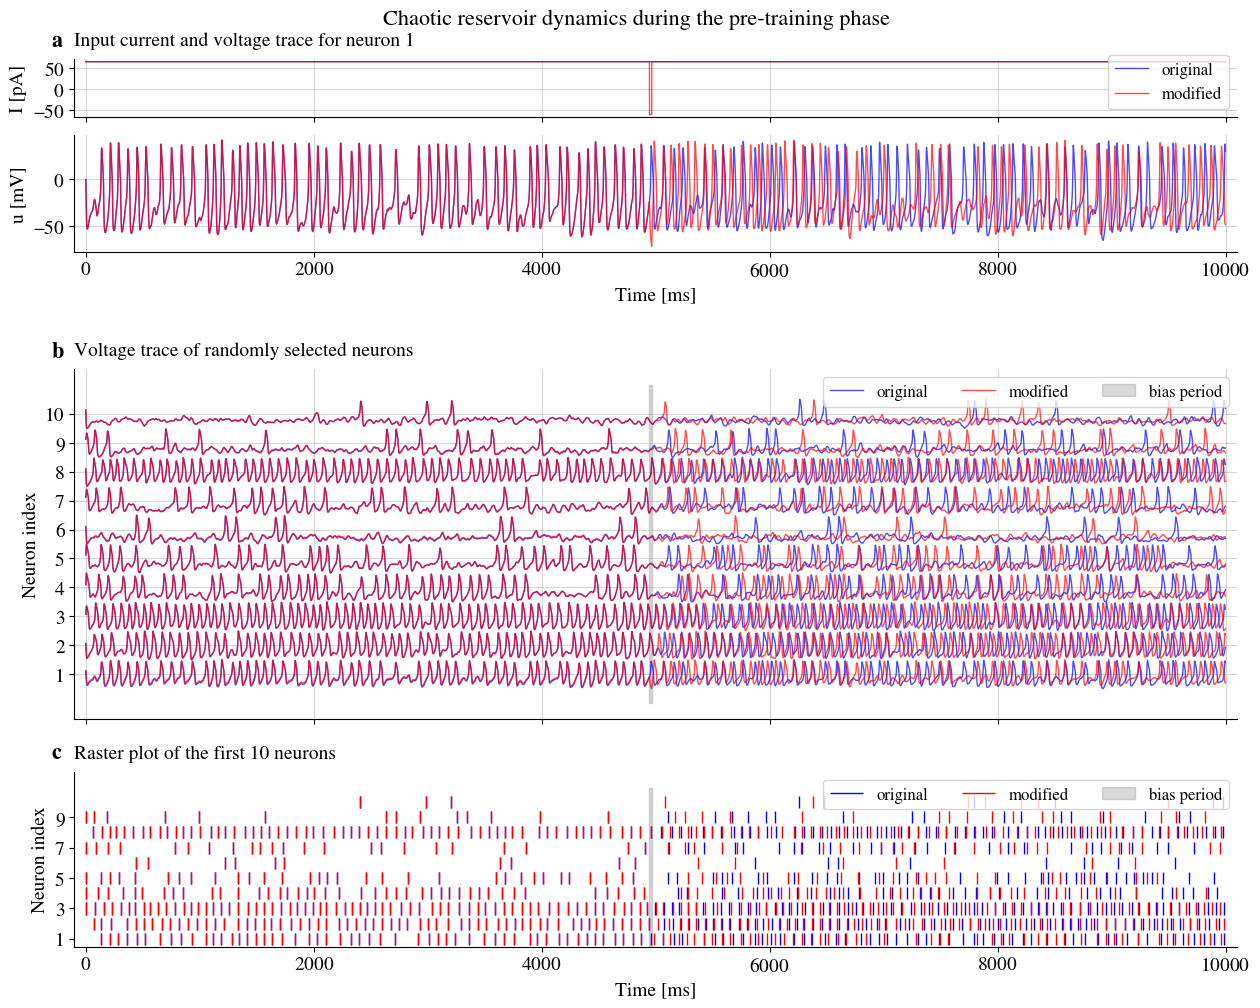

In [22]:
voltage_trace_np = v_trace.numpy()
np.random.seed(seed+21)
rands = np.random.randint(low=0, high=ml.N, size=10)
spike_rands = np.arange(10)
rands = np.arange(10)
step = 10
shift = 7
plot_voltage_trace(
    voltage_trace_np, v_trace_copy.numpy(), spikes_original, spikes_modified, 
    rands, spike_rands, t, figsize=(15, 10), line_alpha=0.7,
    step=step, save_dir=save_dir, extension="pdf", fname="initial_chaos_voltage_trace"
    )

In [ ]:
figure = plt.figure(figsize=(12, 5), layout='tight')
figure.add_subplot(1, 1, 1)
ax = figure.gca()
ax.set_title("Raster plot of the original and modified reservoirs", fontsize=18)
ax.set_xlabel("Time [ms]")
ax.set_ylabel("Neuron index")

# neurons = sorted(rands)
n_neurons = 25
neurons = np.arange(n_neurons)

for i, neuron in enumerate(neurons):
    # Plot the spikes for the original voltage trace
    orig_line = ax.vlines(spikes_original[neuron], i - 0.4, i + 0.4, color='b', lw=1, label="original")
    # Plot the spikes for the modified voltage trace
    modified_line = ax.vlines(spikes_modified[neuron], i - 0.4, i + 0.4, color='r', lw=1, label="spike removed")
# step = 5
fill_line = ax.fill_betweenx([-0.5, n_neurons - 0.5], bias_start, bias_end, color='gray', alpha=0.7, label="bias period")
# ax.set_yticks([i for i in range(len(neurons))[::step]], labels=[str(i) for i in neurons[::step]], minor=True)
ax.legend(loc='upper left', handles=[orig_line, modified_line, fill_line])

# ax.axvline(x=bias_start, color='k', lw=1, ls='-', alpha=.8)
figure.savefig(os.path.join(save_dir, "initial_chaos_raster_plot.pdf"), dpi=300, bbox_inches='tight')
plt.show(figure)